In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# Paths
DATA_DIR = Path("../data/raw/lobster_samples")

# LOBSTER constants
PRICE_SCALE = 10_000  # divide all prices by this
N_LEVELS = 10

# Message file event types
EVENT_TYPES = {
    1: "New Limit Order",
    2: "Partial Cancel",
    3: "Full Cancel",
    4: "Execution (Visible)",
    5: "Execution (Hidden)",
    7: "Trading Halt"
}

# Tickers available
TICKERS = ["AAPL", "AMZN", "GOOG", "INTC", "MSFT"]
DATE = "2012-06-21"

plt.style.use("seaborn-v0_8-darkgrid")
print("Setup complete")

Setup complete


In [2]:
def load_lobster(ticker, date, data_dir, n_levels=10):
    """
    Load and join LOBSTER message and orderbook files.
    Returns a single merged DataFrame with all columns.
    """
    base = f"{ticker}_{date}_34200000_57600000"
    
    # --- Message file ---
    msg_cols = ["time", "event_type", "order_id", "size", "price", "direction"]
    msg = pd.read_csv(
        data_dir / f"{base}_message_{n_levels}.csv",
        header=None,
        names=msg_cols
    )
    msg["price"] = msg["price"] / PRICE_SCALE
    
    # --- Orderbook file ---
    # Columns alternate: ask_price_1, ask_size_1, bid_price_1, bid_size_1, ...
    ob_cols = []
    for i in range(1, n_levels + 1):
        ob_cols += [f"ask_price_{i}", f"ask_size_{i}", 
                    f"bid_price_{i}", f"bid_size_{i}"]
    
    ob = pd.read_csv(
        data_dir / f"{base}_orderbook_{n_levels}.csv",
        header=None,
        names=ob_cols
    )
    
    # Scale prices
    price_cols = [c for c in ob_cols if "price" in c]
    ob[price_cols] = ob[price_cols] / PRICE_SCALE
    
    # Join on row index — they are guaranteed aligned
    df = pd.concat([msg.reset_index(drop=True), ob.reset_index(drop=True)], axis=1)
    
    # Derived columns
    df["mid_price"] = (df["ask_price_1"] + df["bid_price_1"]) / 2
    df["spread"] = df["ask_price_1"] - df["bid_price_1"]
    df["ticker"] = ticker
    
    return df

# Load all tickers
data = {ticker: load_lobster(ticker, DATE, DATA_DIR) for ticker in TICKERS}

# Sanity check
for ticker, df in data.items():
    print(f"{ticker}: {len(df):>7,} events | "
          f"mid_price range: [{df['mid_price'].min():.2f}, {df['mid_price'].max():.2f}] | "
          f"spread mean: {df['spread'].mean():.4f}")

AAPL: 400,391 events | mid_price range: [577.48, 588.18] | spread mean: 0.1535
AMZN: 269,748 events | mid_price range: [220.52, 226.03] | spread mean: 0.1309
GOOG: 147,916 events | mid_price range: [563.73, 579.82] | spread mean: 0.2962
INTC: 624,040 events | mid_price range: [26.62, 27.59] | spread mean: 0.0123
MSFT: 668,765 events | mid_price range: [30.06, 31.14] | spread mean: 0.0123


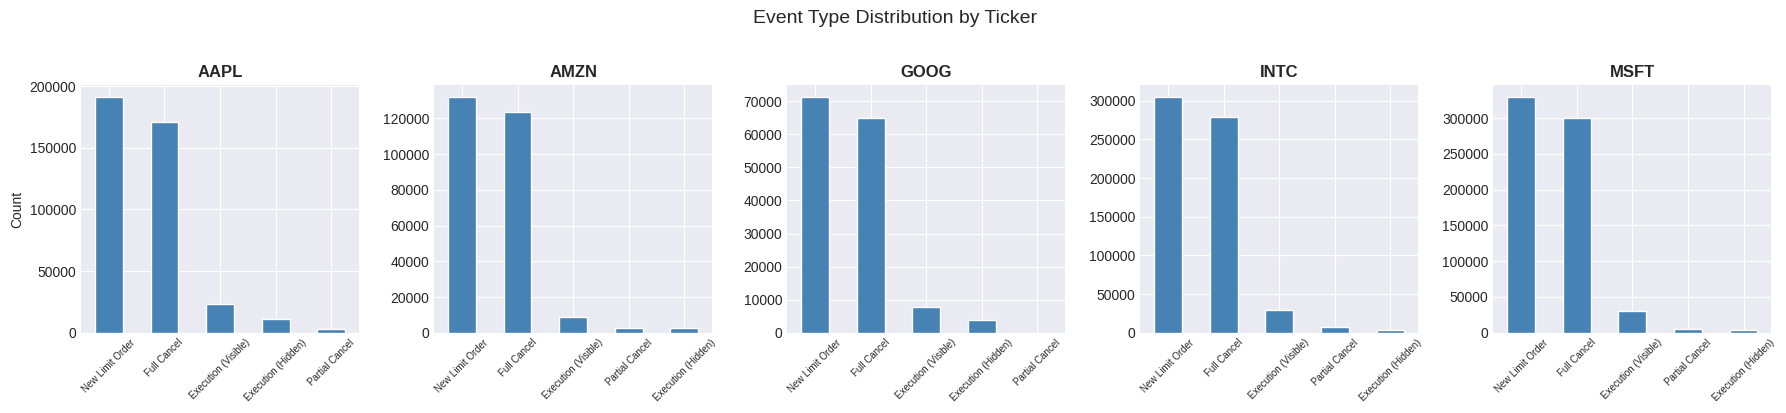

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)

for ax, ticker in zip(axes, TICKERS):
    counts = data[ticker]["event_type"].map(EVENT_TYPES).value_counts()
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(ticker, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.set_ylabel("Count" if ticker == "AAPL" else "")

plt.suptitle("Event Type Distribution by Ticker", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/event_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

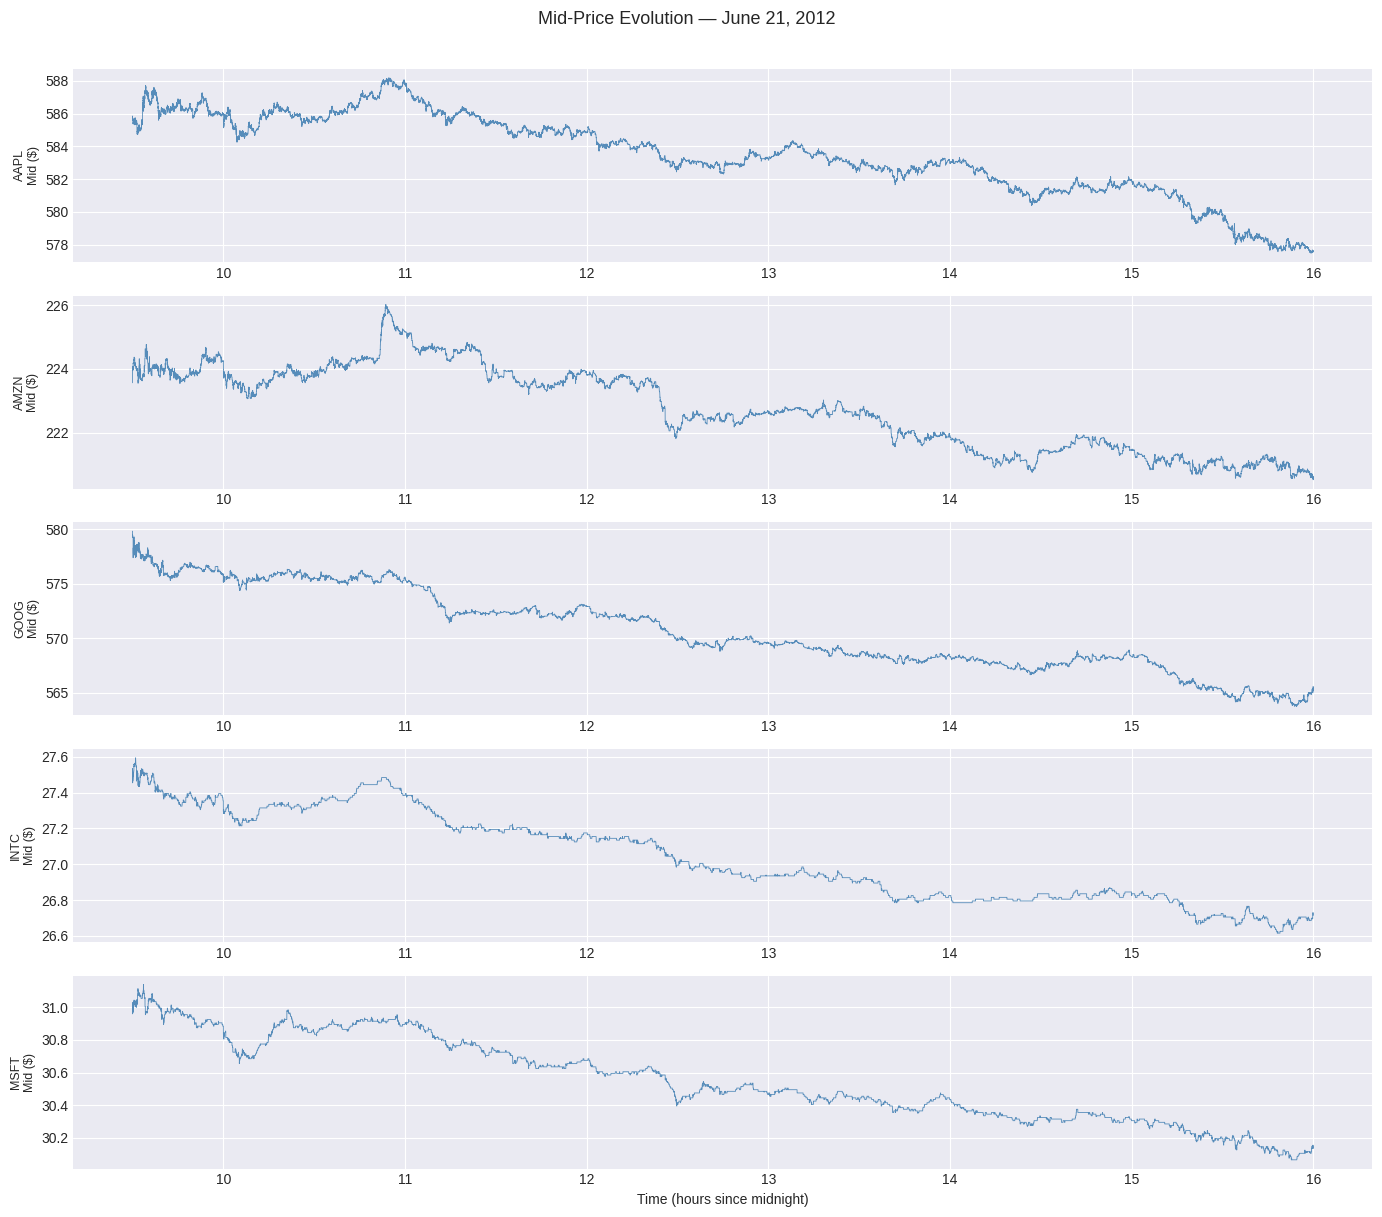

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=False)

for ax, ticker in zip(axes, TICKERS):
    df = data[ticker]
    ax.plot(df["time"] / 3600, df["mid_price"], 
            linewidth=0.6, color="steelblue", alpha=0.9)
    ax.set_ylabel(f"{ticker}\nMid ($)", fontsize=9)
    ax.set_xlabel("")

axes[-1].set_xlabel("Time (hours since midnight)", fontsize=10)
plt.suptitle("Mid-Price Evolution — June 21, 2012", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../results/mid_price_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

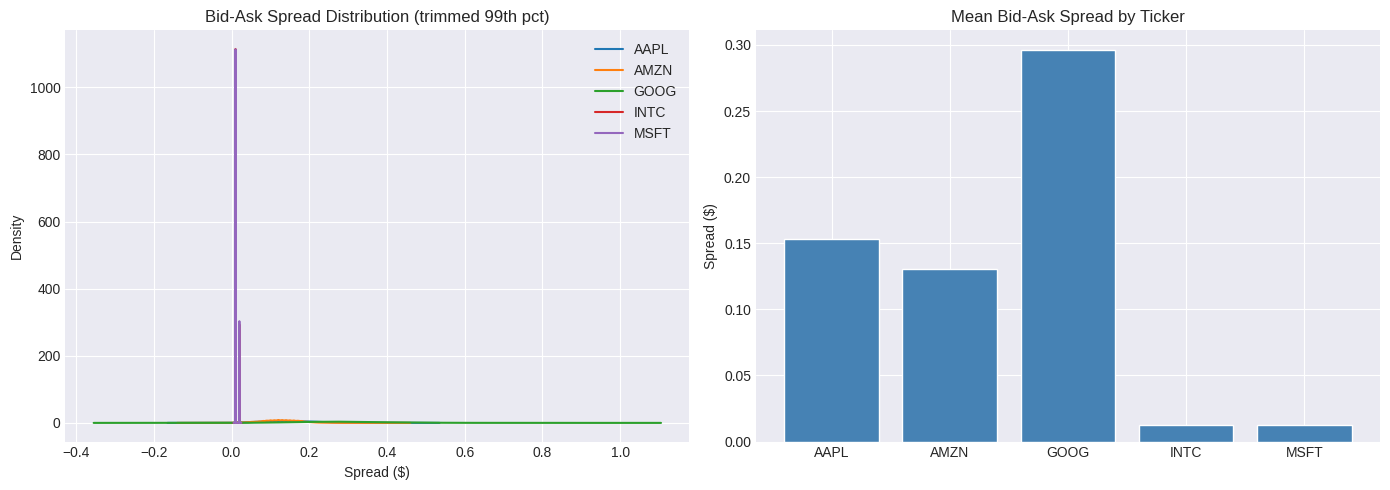

Minimum observed spread (tick size proxy):
  AAPL: $0.0100
  AMZN: $0.0100
  GOOG: $0.0100
  INTC: $0.0100
  MSFT: $0.0100


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
for ticker in TICKERS:
    spread = data[ticker]["spread"]
    spread[spread < spread.quantile(0.99)].plot(
        kind="kde", ax=axes[0], label=ticker, linewidth=1.5
    )

axes[0].set_title("Bid-Ask Spread Distribution (trimmed 99th pct)")
axes[0].set_xlabel("Spread ($)")
axes[0].legend()

# Mean spread per ticker
mean_spreads = {t: data[t]["spread"].mean() for t in TICKERS}
axes[1].bar(mean_spreads.keys(), mean_spreads.values(), color="steelblue", edgecolor="white")
axes[1].set_title("Mean Bid-Ask Spread by Ticker")
axes[1].set_ylabel("Spread ($)")

plt.tight_layout()
plt.savefig("../results/spread_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Print tick sizes (minimum non-zero spread)
print("Minimum observed spread (tick size proxy):")
for t in TICKERS:
    min_spread = data[t]["spread"][data[t]["spread"] > 0].min()
    print(f"  {t}: ${min_spread:.4f}")

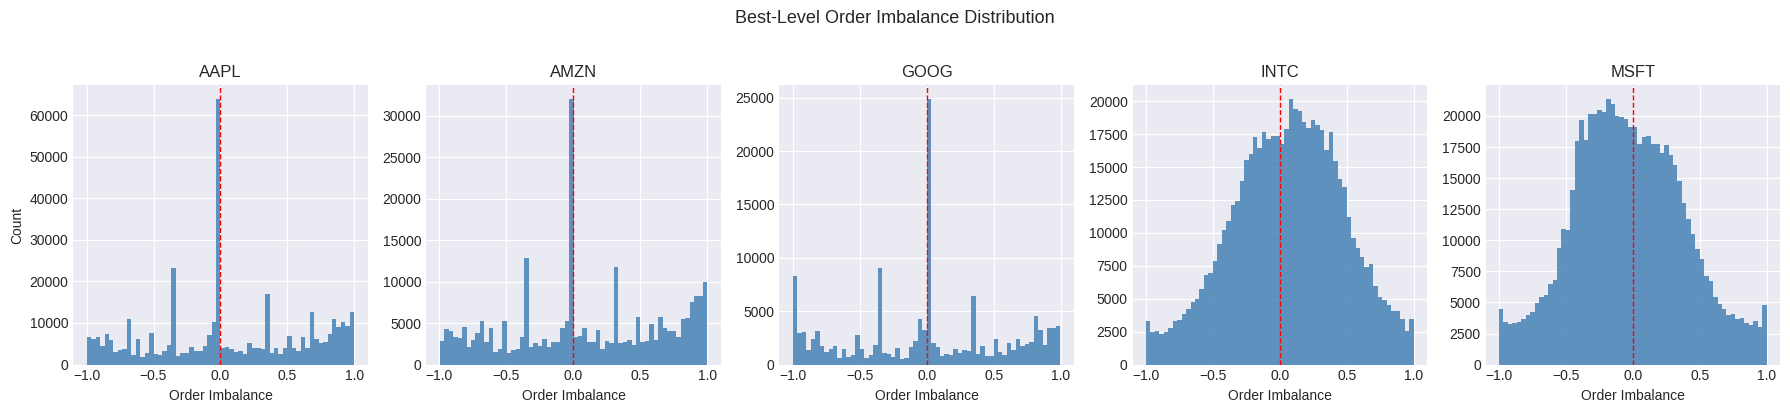

Correlation between OI and next mid-price return:
  AAPL: +0.0316
  AMZN: +0.0409
  GOOG: +0.0267
  INTC: +0.0896
  MSFT: +0.1013


In [6]:
def order_imbalance(df, level=1):
    """
    OI = (bid_size - ask_size) / (bid_size + ask_size)
    Range: [-1, 1]. Positive = more buying pressure.
    """
    bid = df[f"bid_size_{level}"]
    ask = df[f"ask_size_{level}"]
    return (bid - ask) / (bid + ask)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, ticker in zip(axes, TICKERS):
    oi = order_imbalance(data[ticker])
    ax.hist(oi, bins=60, color="steelblue", edgecolor="none", alpha=0.85)
    ax.axvline(0, color="red", linewidth=1, linestyle="--")
    ax.set_title(ticker)
    ax.set_xlabel("Order Imbalance")
    ax.set_ylabel("Count" if ticker == "AAPL" else "")

plt.suptitle("Best-Level Order Imbalance Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/order_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

# Does imbalance predict next mid-price move? Quick check
print("Correlation between OI and next mid-price return:")
for ticker in TICKERS:
    df = data[ticker].copy()
    df["oi"] = order_imbalance(df)
    df["next_return"] = df["mid_price"].shift(-1) - df["mid_price"]
    corr = df[["oi", "next_return"]].dropna().corr().iloc[0, 1]
    print(f"  {ticker}: {corr:+.4f}")